In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("final_sample_dataset.csv")

In [3]:
df.head()

,Text,lables
0,This seems a little more wholesome than some o...,Neutral
1,"The flavors are good. However, I do not see a...",Neutral
2,This is the same stuff you can buy at the big ...,Neutral
3,we're used to spicy foods down here in south t...,Neutral
4,Watch your prices with this. While the assort...,Neutral


In [4]:
df.shape

(109772, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109772 entries, 0 to 109771
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Text    109772 non-null  object
 1   lables  109772 non-null  object
dtypes: object(2)
memory usage: 1.7+ MB


In [6]:
df.isnull().sum()

,0
Text,0
lables,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
import re

In [9]:
def cleaning_text(text):
  text = text.lower()
  text = re.sub(r"[^a-zA-Z0-9\s]", "", text)

  return text

In [10]:
df["Text"] = df["Text"].map(cleaning_text)

In [11]:
df

,Text,lables
0,this seems a little more wholesome than some o...,Neutral
1,the flavors are good however i do not see any...,Neutral
2,this is the same stuff you can buy at the big ...,Neutral
3,were used to spicy foods down here in south te...,Neutral
4,watch your prices with this while the assortm...,Neutral
...,...,...
109767,my first experience with this oil was at what ...,Positive
109768,after trying many evoos were convinced this is...,Positive
109769,love this olive oil it has a great flavor and...,Positive
109770,my daughter has craved this since her trip to ...,Positive


In [12]:
df.duplicated().sum()

np.int64(10)

In [13]:
df = df.drop_duplicates().reset_index(drop=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["lables"].value_counts()

,count
lables,
Positive,40000
Negative,39996
Neutral,29766


In [16]:
df["lables"] = df["lables"].replace({
    "Positive":0,
    "Negative":1,
    "Neutral":2
})

/tmp/ipykernel_2858/1430323937.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["lables"] = df["lables"].replace({


In [17]:
df

,Text,lables
0,this seems a little more wholesome than some o...,2
1,the flavors are good however i do not see any...,2
2,this is the same stuff you can buy at the big ...,2
3,were used to spicy foods down here in south te...,2
4,watch your prices with this while the assortm...,2
...,...,...
109757,my first experience with this oil was at what ...,0
109758,after trying many evoos were convinced this is...,0
109759,love this olive oil it has a great flavor and...,0
109760,my daughter has craved this since her trip to ...,0


In [18]:
X = df["Text"]
y = df["lables"]

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [21]:
X_train

,Text
67416,the product is a small hard disc of dried chic...
101986,if you are looking for a nutty snack that is n...
9970,these beans were just okay i probably will not...
40681,i usually never write a review but i feel comp...
39155,beware these small bars have nearly as many ca...
...,...
54886,the new good earth original caffeine free tea ...
76820,a very interesting and fun way to spend an eve...
103694,i mean wow the removable table is awesome defi...
860,i am a little dis appointed with this tea th...


In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [23]:
max_features = 40000
tokenizer = Tokenizer(num_words=max_features)

In [24]:
tokenizer.fit_on_texts(X_train)

In [25]:
len(tokenizer.word_index)

90667

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
X_train_seq

[[1,
  35,
  8,
  4,
  168,
  190,
  4862,
  7,
  495,
  270,
  1688,
  5,
  27,
  9659,
  200,
  17,
  303,
  1034,
  3,
  3295,
  165,
  36,
  114,
  10,
  776,
  26,
  3234,
  51,
  95,
  507,
  1135,
  10,
  6,
  15,
  107,
  16,
  331,
  4297,
  6951,
  77,
  60,
  4001,
  47,
  57,
  888,
  9,
  35],
 [31,
  19,
  20,
  192,
  11,
  4,
  1640,
  296,
  12,
  8,
  14,
  72,
  125,
  9,
  248,
  27,
  11,
  19,
  15,
  476,
  3,
  2,
  253,
  87,
  30,
  112,
  2387,
  9,
  8,
  46,
  7,
  4,
  234,
  518,
  291,
  112,
  378,
  1,
  262,
  503,
  17,
  33,
  4,
  135,
  7,
  4,
  484,
  29,
  3,
  179,
  2,
  378,
  30,
  2,
  42,
  160,
  21,
  20,
  249,
  10,
  1,
  315,
  518,
  2818,
  73,
  2,
  16,
  618,
  11,
  130,
  499,
  1346,
  57,
  253,
  378,
  12,
  1,
  1251,
  16,
  14,
  4,
  333,
  174,
  10,
  75,
  667,
  318,
  7,
  406,
  12,
  202,
  19,
  329,
  11,
  130,
  5,
  5730,
  75,
  1255,
  4132,
  23,
  57,
  253,
  590,
  30,
  179,
  2,
  61,
  129,
  12,


In [ ]:
len(X_train_seq)

76833

In [ ]:
max_length = [len(i) for i in X_train_seq]

p95 = int(np.percentile(max_length, 95))
p95

224

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen=p95, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=p95, padding="post", truncating="post")

In [ ]:
X_train_pad

array([[   1,   35,    8, ...,    0,    0,    0],
       [  31,   19,   20, ...,    0,    0,    0],
       [  28,  369,   60, ...,    0,    0,    0],
       ...,
       [   2,  884, 1121, ...,    0,    0,    0],
       [   2,   91,    4, ...,    0,    0,    0],
       [   2,  485,    9, ...,    0,    0,    0]], dtype=int32)

In [ ]:
X_train_pad.shape

(76833, 224)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout, Embedding, GRU

In [ ]:
embedding_length = 64
model = Sequential([
    Embedding(max_features, embedding_length, input_length=p95),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(64)),
    Dropout(0.2),
    Dense(3, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
early_stopping = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

In [ ]:
history = model.fit(X_train_pad, y_train, batch_size=32, epochs=15, callbacks=early_stopping, validation_split=0.2)

Epoch 1/15
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 78s 39ms/step - accuracy: 0.5557 - loss: 0.9296 - val_accuracy: 0.5175 - val_loss: 1.0027
Epoch 2/15
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.6814 - loss: 0.7132 - val_accuracy: 0.6971 - val_loss: 0.6879
Epoch 3/15
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 73s 38ms/step - accuracy: 0.7591 - loss: 0.5648 - val_accuracy: 0.7169 - val_loss: 0.6417
Epoch 4/15
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 73s 38ms/step - accuracy: 0.8096 - loss: 0.4768 - val_accuracy: 0.7250 - val_loss: 0.6480
Epoch 5/15
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 73s 38ms/step - accuracy: 0.8441 - loss: 0.3974 - val_accuracy: 0.7188 - val_loss: 0.6896
Epoch 6/15
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 77s 40ms/step - accuracy: 0.8796 - loss: 0.3193 - val_accuracy: 0.7153 - val_loss: 0.7783


In [ ]:
y_pred = model.predict(X_test_pad)

1030/1030 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step


In [ ]:
y_pred = np.argmax(y_pred, axis=1)

In [ ]:
accuracy_score(y_test, y_pred)

0.7206110115703483

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

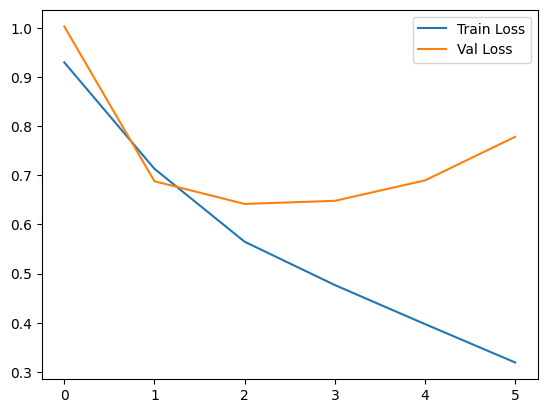

In [ ]:
plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()

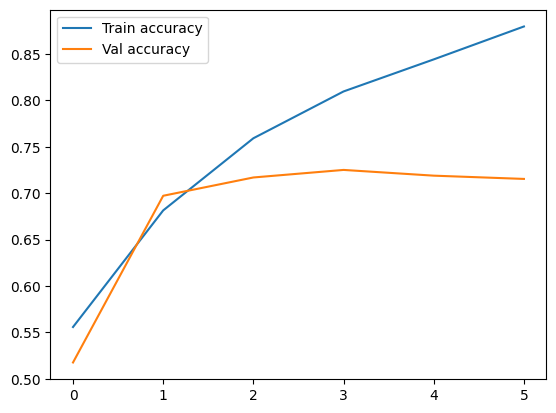

In [ ]:
plt.figure()
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Val accuracy")
plt.legend()

In [ ]:
pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T

,precision,recall,f1-score,support
0,0.834527,0.816011,0.825165,11854.000000
1,0.778915,0.681367,0.726882,12177.000000
2,0.538929,0.647224,0.588133,8898.000000
accuracy,0.720611,0.720611,0.720611,0.720611
macro avg,0.717457,0.714867,0.713394,32929.000000
weighted avg,0.734086,0.720611,0.724770,32929.000000


<Axes: >

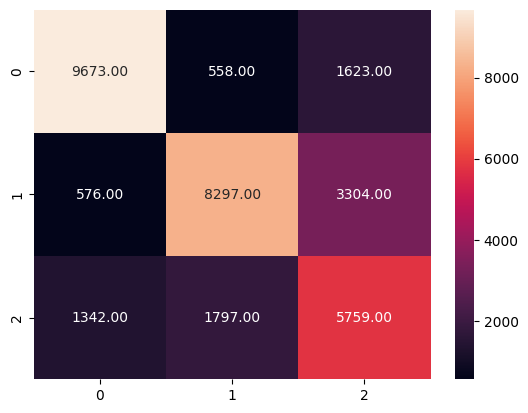

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt=".2f")

In [ ]:
model.save("amazon_reviews_prediction_model.keras")

In [27]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)